# 🚀 Quick Commerce Data Analysis

======================================================

### Quick Commerce (Q-Commerce) Analytics Dataset

This is a synthetic Quick Commerce (Q-Commerce) dataset simulating real-world order data from platforms like Blinkit, Zepto, Swiggy Instamart, and others. 

It contains rich order-level features such as city, category, delivery time, ratings, discounts, and revenue, making it ideal for practicing data cleaning, EDA, visualization, dashboard building, and extracting business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('quick_commerce_data_raw.csv')

In [3]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  str    
 2   City                     948000 non-null   str    
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  str    
 9   Payment_Method           1000000 non-null  str    
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), str(4)
memory usage: 99.2 MB


In [5]:
df.shape

(1000000, 13)

In [6]:
df.isnull().sum() * 100 / len(df)

Order_ID                    0.0000
Company                     0.0000
City                        5.2000
Customer_Age                0.0000
Order_Value                 0.0000
Delivery_Time_Min           0.0000
Distance_Km                 0.0000
Items_Count                 3.5000
Product_Category            0.0000
Payment_Method              0.0000
Customer_Rating             4.7000
Discount_Applied            0.0000
Delivery_Partner_Rating    10.4137
dtype: float64

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.city.unique()

<StringArray>
[    'Noida',  'Amritsar',    'Mumbai',     'Delhi',   'Kolkata',  'Bengluru',
   'Chennai', 'Hyderabad',      'Pune',  'Haridwar',    'Jaipur',         nan,
   'Gurgaon']
Length: 13, dtype: str

In [9]:
df.city = df.city.fillna('Unknown')

In [10]:
df.items_count.unique()

array([12., 10., nan,  2., 13., 15., 19.,  5., 16.,  9.,  4., 14., 18.,
        3.,  7.,  8.,  6.,  1., 17., 11.])

In [11]:
df.items_count = df.items_count.fillna(df.items_count.median())

In [12]:
df.items_count.unique()

array([12., 10.,  2., 13., 15., 19.,  5., 16.,  9.,  4., 14., 18.,  3.,
        7.,  8.,  6.,  1., 17., 11.])

In [13]:
df.customer_rating.unique()

array([2.1, 2.3, 3.3, 5. , 3.7, 3.1, 2.8, 3.4, 2.5, 1.6, 3.5, 4.8, 2.4,
       2.6, 4.1, 2.4, 1.7, nan, 1. , 2.7, 2.2, 3.4, 4.7, 1.2, 3.9, 4.3,
       3.8, 1.2, 1.3, 3.4, 3.2, 1.8, 2. , 1.7, 1.1, 4. , 4.6, 3. , 2.9,
       1.9, 4.2, 2.3, 2.8, 4.5, 4.4, 1.7, 3.6, 4.3, 3.3, 4.1, 4.6, 1.8,
       1.4, 4.2, 1.5, 4. , 4.9, 1.3, 1.6, 1.3, 2.9, 3. , 3.5, 1.5, 4.8,
       4.7, 3.3, 4.7, 2.9, 1.5, 1.5, 1. , 3.7, 4.5, 2.5, 3.1, 1.2, 4.3,
       1.8, 5. , 4.5, 3.6, 4.2, 4.8, 1.1, 3.6, 2.6])

In [14]:
df.customer_rating = df.customer_rating.fillna(df.customer_rating.mean()).round()

In [15]:
df

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,4.0,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.0,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.0,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.0,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [16]:
df.order_value = df.order_value.astype('float').round(3)

In [17]:
df

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.660,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.059,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.026,12.470,2.45,13.0,Household,Wallet,4.0,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.330,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.0,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.663,18.306,10.51,9.0,Beverages,Debit Card,4.0,1,3.5
999997,1999998,Jio Mart,Noida,29,637.323,17.590,2.65,6.0,Groceries,Cash on Delivery,3.0,0,4.6
999998,1999999,Dunzo,Pune,42,1103.121,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [18]:
df.isnull().sum() * 100 / len(df)

order_id                    0.0000
company                     0.0000
city                        0.0000
customer_age                0.0000
order_value                 0.0000
delivery_time_min           0.0000
distance_km                 0.0000
items_count                 0.0000
product_category            0.0000
payment_method              0.0000
customer_rating             0.0000
discount_applied            0.0000
delivery_partner_rating    10.4137
dtype: float64

In [19]:
df.delivery_partner_rating.unique()

array([3.2, 3.8, 5. , 4.8, 4.9, nan, 2.7, 4. , 4.4, 2.6, 4.5, 4.1, 4.6,
       2.8, 2.5, 3.6, 3. , 3.1, 3.5, 4.7, 4.2, 2.9, 3.3, 3.7, 4.3, 3.9,
       3.4])

In [20]:
df.delivery_partner_rating = df.delivery_partner_rating.fillna(df.delivery_partner_rating.mean()).round(1)


In [21]:
df.delivery_partner_rating.unique()

array([3.2, 3.8, 5. , 4.8, 4.9, 3.7, 2.7, 4. , 4.4, 2.6, 4.5, 4.1, 4.6,
       2.8, 2.5, 3.6, 3. , 3.1, 3.5, 4.7, 4.2, 2.9, 3.3, 4.3, 3.9, 3.4])

In [22]:
df.isnull().sum() * 100 / len(df)

order_id                   0.0
company                    0.0
city                       0.0
customer_age               0.0
order_value                0.0
delivery_time_min          0.0
distance_km                0.0
items_count                0.0
product_category           0.0
payment_method             0.0
customer_rating            0.0
discount_applied           0.0
delivery_partner_rating    0.0
dtype: float64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.660,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.059,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.026,12.470,2.45,13.0,Household,Wallet,4.0,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.330,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.0,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.663,18.306,10.51,9.0,Beverages,Debit Card,4.0,1,3.5
999997,1999998,Jio Mart,Noida,29,637.323,17.590,2.65,6.0,Groceries,Cash on Delivery,3.0,0,4.6
999998,1999999,Dunzo,Pune,42,1103.121,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


## Q.1) Which quick commerce platform has the highest total revenue?

In [25]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


C:\Users\Admin\AppData\Local\Temp\ipykernel_19428\1354418101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_19428\1354418101.py:6: UserWarning: 
The palette list has fewer values (3) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])


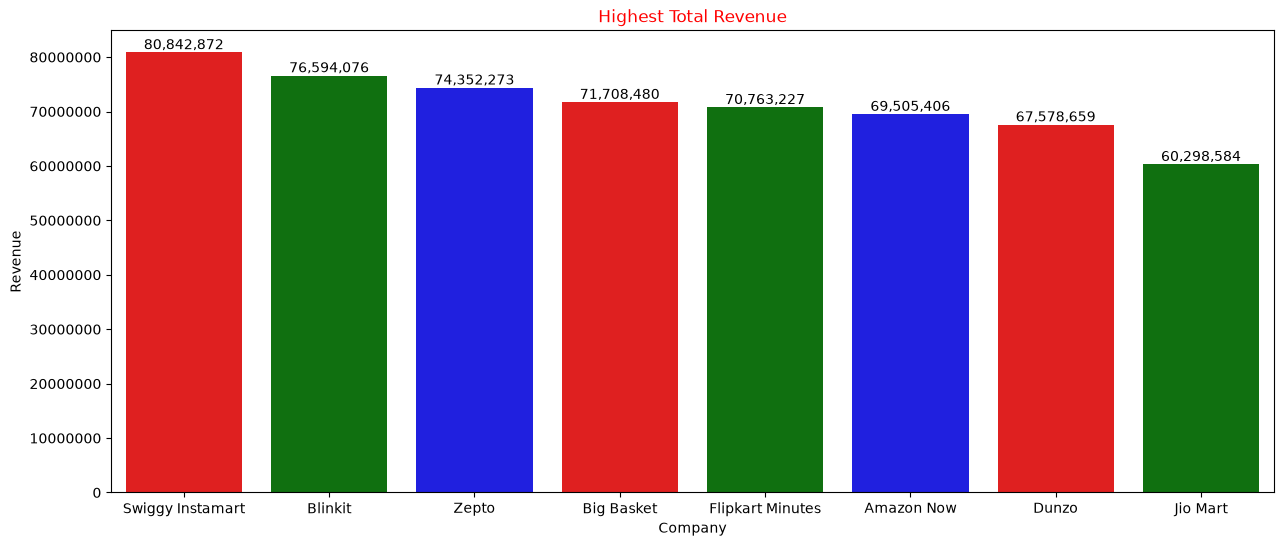

In [26]:
plots = df.groupby('company')['order_value'].sum().sort_values(ascending=False)
plt.figure(figsize=(15,6))
plt.title('Highest Total Revenue', color = 'Red')
plt.xlabel('Company')
plt.ylabel('Revenue')
ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
for i in ax.containers:
    ax.bar_label(i,fmt='{:,.0f}')

## Q.2) Which platform has the highest average order value (AOV)?

In [27]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


C:\Users\Admin\AppData\Local\Temp\ipykernel_19428\1231430084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_19428\1231430084.py:6: UserWarning: 
The palette list has fewer values (3) than needed (8) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])


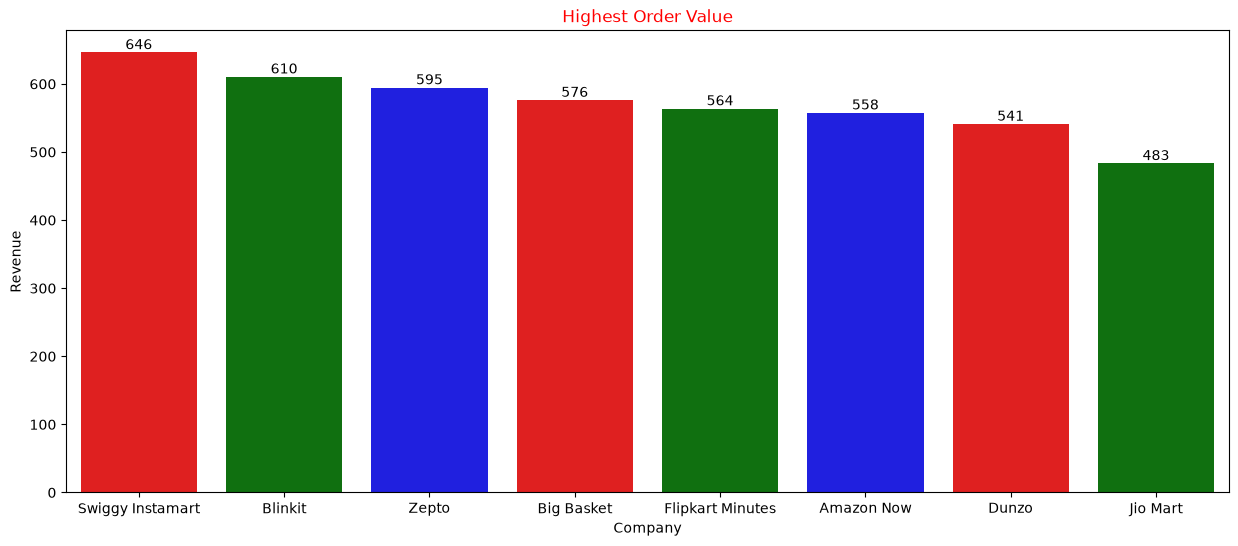

In [28]:
plots = df.groupby('company')['order_value'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,6))
plt.title('Highest Order Value', color = 'Red')
plt.xlabel('Company')
plt.ylabel('Revenue')
ax = sns.barplot(x = plots.index, y = plots.values, palette=['red','green','blue'])
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
for i in ax.containers:
    ax.bar_label(i,fmt='{:,.0f}')

## Q.3) How does Customer Rating vary across platforms?

In [29]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


In [30]:
df.groupby('company').customer_rating.mean().round()

company
Amazon Now          3.0
Big Basket          3.0
Blinkit             4.0
Dunzo               2.0
Flipkart Minutes    3.0
Jio Mart            3.0
Swiggy Instamart    3.0
Zepto               3.0
Name: customer_rating, dtype: float64

## Q.4) Does 'Delivery Time' affects the 'Delivery Partner Ratings'?

In [31]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


<Axes: xlabel='delivery_partner_rating'>

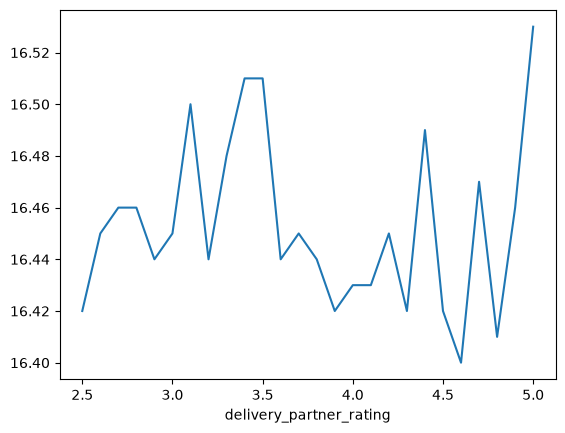

In [32]:
df.groupby('delivery_partner_rating').delivery_time_min.mean().round(2).plot()

## Q.5) What is the most popular Product Category on Swiggy Instamart, for the people of age between 30-40, in Mumbai?

In [33]:
df.head()

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.660,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.059,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.026,12.470,2.45,13.0,Household,Wallet,4.0,0,4.8


In [34]:
df[(df.customer_age.isin([30,40])) & (df.company == 'Swiggy Instamart') & (df.city == 'Mumbai')]['product_category'].value_counts()

product_category
Dairy                  76
Groceries              75
Personal Care          72
Snacks                 71
Fruits & Vegetables    68
Beverages              63
Household              62
Name: count, dtype: int64

### Q.6) Which cities should these company expand into based on performance?

In [35]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


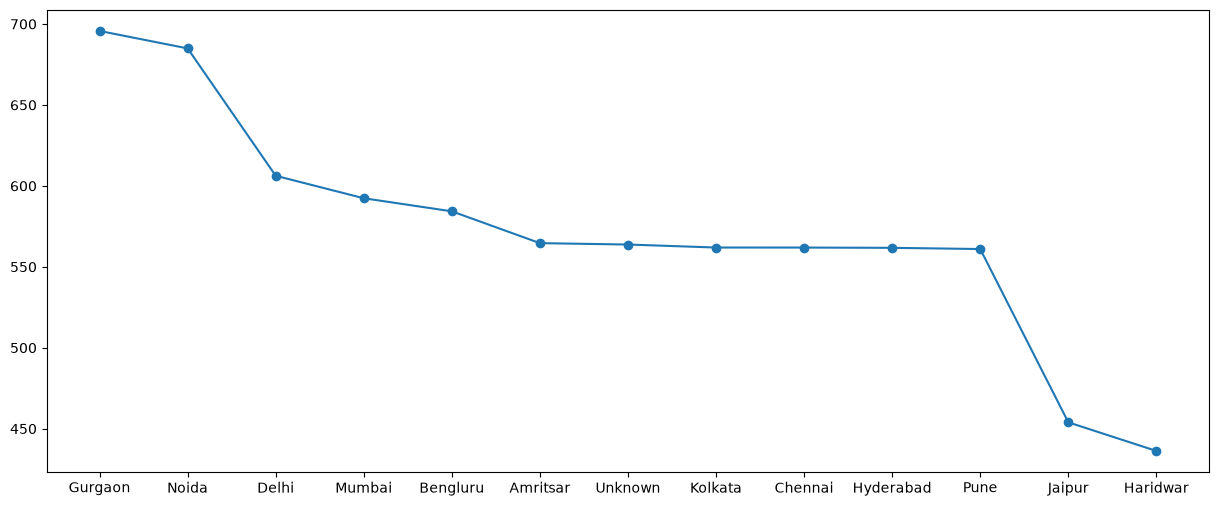

In [45]:
plots = df.groupby('city').order_value.mean().round(3).sort_values(ascending=False)
plt.figure(figsize=(15,6))
plt.plot(plots.index, plots.values, marker = 'o')

## Q.7) Are discounts increasing order volume or just reducing revenue?

In [46]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,0,3.2


In [51]:
df.discount_applied.unique()

array([1, 0])

In [54]:
df['discount_applied'] = df['discount_applied'].replace([0,1],['No','Yes'])


<Axes: xlabel='discount_applied'>

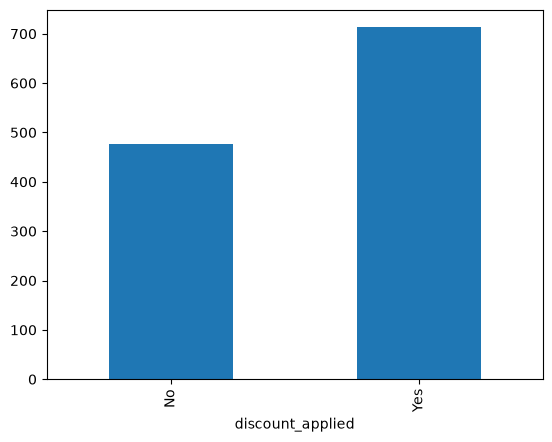

In [65]:
df.groupby('discount_applied').order_value.mean().plot(kind = 'bar')

In [64]:
df.discount_applied.unique()

array(['Yes', 'No'], dtype=object)

In [56]:
df

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating,dis_applied
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,Yes,3.2,
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,No,3.2,
2,1000003,Flipkart Minutes,Mumbai,18,1211.660,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,No,3.8,
3,1000004,Swiggy Instamart,Delhi,23,1179.059,5.864,6.44,2.0,Dairy,Credit Card,5.0,Yes,5.0,
4,1000005,Dunzo,Mumbai,44,586.026,12.470,2.45,13.0,Household,Wallet,4.0,No,4.8,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.330,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.0,No,2.8,
999996,1999997,Swiggy Instamart,Mumbai,33,1509.663,18.306,10.51,9.0,Beverages,Debit Card,4.0,Yes,3.5,
999997,1999998,Jio Mart,Noida,29,637.323,17.590,2.65,6.0,Groceries,Cash on Delivery,3.0,No,4.6,
999998,1999999,Dunzo,Pune,42,1103.121,12.656,7.76,12.0,Snacks,Wallet,4.0,Yes,4.5,


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   order_id                 1000000 non-null  int64  
 1   company                  1000000 non-null  str    
 2   city                     1000000 non-null  str    
 3   customer_age             1000000 non-null  int64  
 4   order_value              1000000 non-null  float64
 5   delivery_time_min        1000000 non-null  float64
 6   distance_km              1000000 non-null  float64
 7   items_count              1000000 non-null  float64
 8   product_category         1000000 non-null  str    
 9   payment_method           1000000 non-null  str    
 10  customer_rating          1000000 non-null  float64
 11  discount_applied         1000000 non-null  object 
 12  delivery_partner_rating  1000000 non-null  float64
 13  dis_applied              1000000 non-null  str    
dty

In [58]:
df.drop(columns='dis_applied',inplace=True)

In [59]:
df

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,Yes,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,No,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.660,16.910,4.85,10.0,Personal Care,Cash on Delivery,3.0,No,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.059,5.864,6.44,2.0,Dairy,Credit Card,5.0,Yes,5.0
4,1000005,Dunzo,Mumbai,44,586.026,12.470,2.45,13.0,Household,Wallet,4.0,No,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.330,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.0,No,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.663,18.306,10.51,9.0,Beverages,Debit Card,4.0,Yes,3.5
999997,1999998,Jio Mart,Noida,29,637.323,17.590,2.65,6.0,Groceries,Cash on Delivery,3.0,No,4.6
999998,1999999,Dunzo,Pune,42,1103.121,12.656,7.76,12.0,Snacks,Wallet,4.0,Yes,4.5


## Q.8) Which company has the Best Operational Efficiency (Delivery Time vs Order Volume)?

In [66]:
df.head(2)

,order_id,company,city,customer_age,order_value,delivery_time_min,distance_km,items_count,product_category,payment_method,customer_rating,discount_applied,delivery_partner_rating
0,1000001,Swiggy Instamart,Noida,46,702.338,19.182,11.97,12.0,Dairy,Wallet,2.0,Yes,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.300,19.644,12.74,10.0,Snacks,Cash on Delivery,2.0,No,3.2


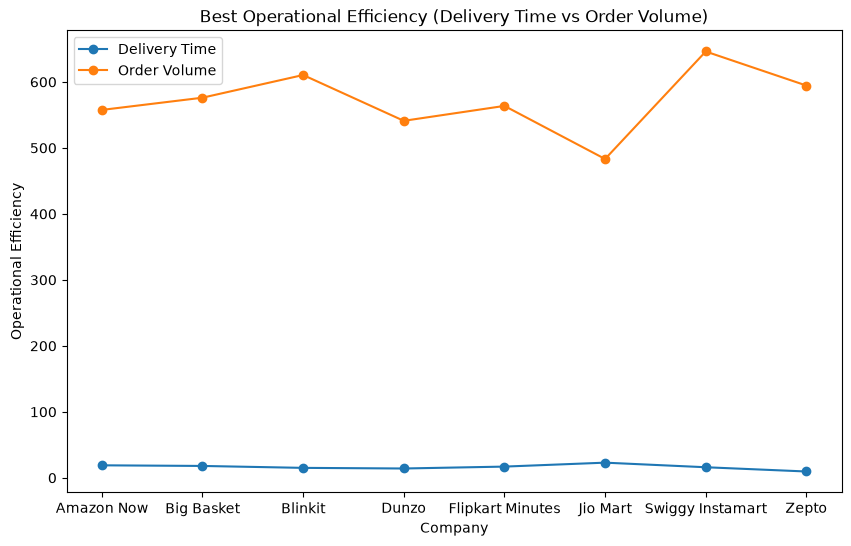

In [82]:
del_time = df.groupby('company').delivery_time_min.mean()
ord_vol = df.groupby('company').order_value.mean()
plt.figure(figsize=(10,6))
plt.title('Best Operational Efficiency (Delivery Time vs Order Volume)')
plt.xlabel('Company')
plt.ylabel('Operational Efficiency')
plt.plot(del_time.index, del_time.values,label = 'Delivery Time', marker = 'o')
plt.plot(ord_vol.index, ord_vol.values,label = 'Order Volume', marker = 'o')
plt.legend()